In [7]:
import os
import torch
DATA_FOLDER = "/kaggle/input/datasets/jonathanoheix/face-expression-recognition-dataset/images"
TRAIN_DATA_FOLDER = os.path.join(DATA_FOLDER, "train")
TEST_DATA_FOLDER = os.path.join(DATA_FOLDER, "validation")
seed = 0
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

### 1) EDA

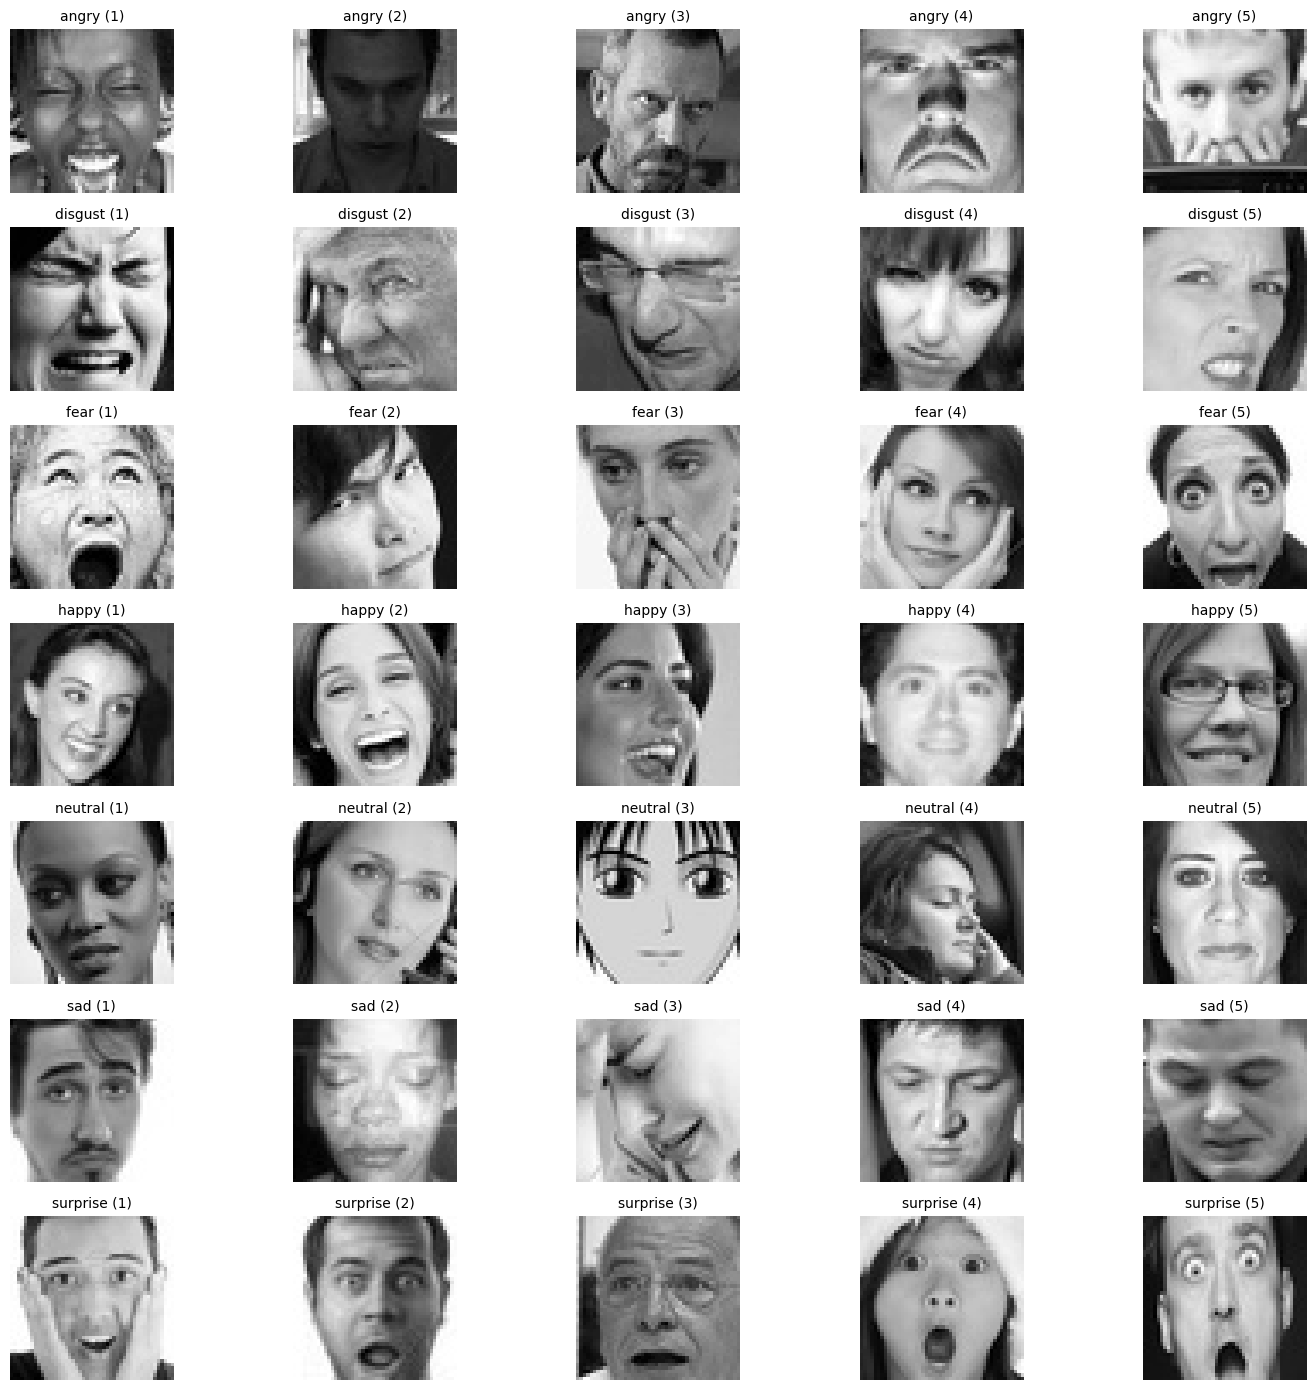

In [2]:
import os
import matplotlib.pyplot as plt
from PIL import Image

emotions = sorted(os.listdir(TRAIN_DATA_FOLDER))
num_samples = 5

fig, axes = plt.subplots(len(emotions), num_samples, figsize=(15, 2 * len(emotions)))
for row, emotion in enumerate(emotions):
    emotion_path = os.path.join(TRAIN_DATA_FOLDER, emotion)
    img_names = [f for f in os.listdir(emotion_path)]
    for col in range(num_samples):
        ax = axes[row, col]
        if col < len(img_names):
            img_path = os.path.join(emotion_path, img_names[col])
            img = Image.open(img_path)
            
            ax.imshow(img, cmap='gray' if img.mode == 'L' else None)
            ax.set_title(f"{emotion} ({col+1})", fontsize=10)
        ax.axis('off')
plt.tight_layout()
plt.show()

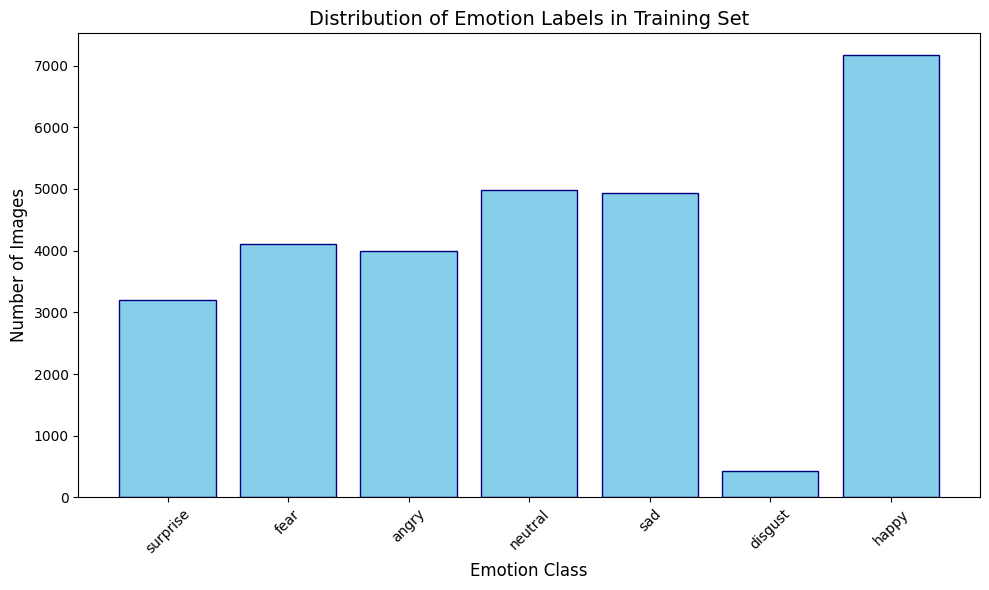

In [3]:
import matplotlib.pyplot as plt

label_dirs = [d for d in os.listdir(TRAIN_DATA_FOLDER)]
label_counts = {}
    
for label in label_dirs:
    label_path = os.path.join(TRAIN_DATA_FOLDER, label)
    images = [f for f in os.listdir(label_path)]
    label_counts[label] = len(images)
    
# Bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(label_counts.keys(), label_counts.values(), color='skyblue', edgecolor='navy')
plt.title('Distribution of Emotion Labels in Training Set', fontsize=14)
plt.xlabel('Emotion Class', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2) Data Preprocessing and Loading

In [4]:
import os
import torch
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, WeightedRandomSampler, Dataset

# Configuration
BATCH_SIZE = 128
IMG_SIZE = (48, 48)

# Transform Pipelines
"""
This will apply data augmentation to the training set (random horizontal flip and random rotation) 
while keeping the validation and test sets unchanged except for resizing and normalization. 
The normalization values are based on the mean and standard deviation of the training dataset
"""
train_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    # Image has 50% chance of horizontal flipping
    transforms.RandomHorizontalFlip(),
    # Rotate the image by a random angle between -15 and 15 degrees
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4913, 0.4913, 0.4913], std=[0.2471, 0.2471, 0.2471])
])

test_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4913, 0.4913, 0.4913], std=[0.2471, 0.2471, 0.2471])
])

"""
Custom Wrapper for Different Transforms
Essentially it inherits from Dataset which expects __getitem__ and __len__ methods to be implemented.
__getitem__ retrieves an item from the underlying dataset and applies the 
specified transform to the image (x) before returning it along with its label (y).
"""
class ApplyTransform(Dataset):
    def __init__(self, data, transform=None):
        self.data = data
        self.transform = transform
        
    def __getitem__(self, index):
        x, y = self.data[index]
        if self.transform:
            x = self.transform(x)
        return x, y
        
    def __len__(self):
        return len(self.data)

# Load and Split Dataset
full_train_dataset = datasets.ImageFolder(root=TRAIN_DATA_FOLDER)
test_dataset = datasets.ImageFolder(root=TEST_DATA_FOLDER)

# Perform 80/20 split
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_subset, val_subset = random_split(
    full_train_dataset, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# Apply specific transforms to each subset
train_dataset = ApplyTransform(train_subset, transform=train_transform)
val_dataset = ApplyTransform(val_subset, transform=test_transform)
test_dataset = ApplyTransform(test_dataset, transform=test_transform)

target_classes = full_train_dataset.classes

# Weighted Sampler for Training
class_weights = [0.14, 0.17, 0.14, 0.13, 0.14, 0.14, 0.14]
train_targets = [full_train_dataset.targets[i] for i in train_subset.indices]
weights = np.array([class_weights[t] for t in train_targets])
sample_weights = torch.from_numpy(weights).double()

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# DataLoaders, for loading data in batches and shuffling for training
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, pin_memory=True, num_workers=os.cpu_count())
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True, num_workers=os.cpu_count())
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True, num_workers=os.cpu_count())

print(f"Classes: {target_classes}")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Training samples: 23056
Validation samples: 5765
Test samples: 7066


### 3) Define Model

In [5]:
import torch
import torch.nn as nn
class OurModel(nn.Module):
    def __init__(self, num_classes=7):
        """
        Define the architecture of our model

        Args:
        num_classes (int): The number of output classes for the classifier. 
                           (In this case, it is 7 for the emotions dataset).
        """
        super(OurModel, self).__init__()
        ##############
        # Your code here
        self.stage1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(), 
            nn.MaxPool2d(kernel_size = 2, stride = 2)
        )
    
        self.stage2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2))
        
        self.stage3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2))

        self.stage4 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU())
                
        self.global_pool = torch.nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.2))
        self.fc1 = nn.Sequential(
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Dropout(0.2))
        self.fc2= nn.Sequential(
            nn.Linear(128, num_classes))
        ##############
        
    def forward(self, x):
        """
        Performs the forward pass of the OurModel.

        Args:
        x (torch.Tensor): The input tensor, typically with shape (batch_size, channels, height, width).
                          For this lab, input is (B, 3, 48, 48), so we are representing
                          the grayscale image in RGB format where R=G=B
        Returns:
        torch.Tensor: The output logits with shape (batch_size, num_classes).
        """
        ##############
        # Your code here
        out = self.stage1(x)
        out = self.stage2(out)
        out = self.stage3(out)
        out = self.stage4(out)
        out = self.global_pool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)
        out = self.fc1(out)
        out = self.fc2(out)
        return out
        ##############

### 4) Training

In [ ]:
from tqdm import tqdm
from functools import partial
import torch
from typing import Dict, List, Tuple
from torch.utils import tensorboard
from pathlib import Path
import os
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from torchmetrics.classification import MulticlassF1Score

tqdm = partial(tqdm, position=0, leave=True)

def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device: torch.device,
               epoch_num: int) -> Tuple[float, float]:
    """
    Performs a single training epoch.

    Args:
        model (torch.nn.Module): The neural network model to train.
        dataloader (torch.utils.data.DataLoader): DataLoader providing the training data batches.
        loss_fn (torch.nn.Module): The loss function to minimize (e.g., CrossEntropyLoss).
        optimizer (torch.optim.Optimizer): The optimizer to update model parameters (e.g., Adam).
        device (torch.device): The device (CPU or GPU) where computations will be performed.
        epoch_num (int): The current epoch number, primarily used for logging or progress bars.

    Returns:
        Tuple[float, float]: A tuple containing:
            - Average training loss for the epoch.
            - Average training accuracy for the epoch.
    """

    # Its a good idea to use tqdm to monitor the progress 
    # by tracking the current loss, accuracy every batch 
    ################
    # Your code here
    model.train()

    accumulated_loss = 0
    num_correct = 0
    num_samples = 0
    # Loop through data loader data batches
    for batch, (X, y) in enumerate(pbar := tqdm(dataloader, desc = "Epoch " + str(epoch_num), unit = "batch")):
        X, y = X.to(device), y.to(device)

        pred = model(X)

        # Compute loss
        loss = loss_fn(pred, y)
        accumulated_loss += loss.item() * len(y)
        # Reset gradient
        optimizer.zero_grad()

        # Compute gradient
        loss.backward()

        # Update
        optimizer.step()

        pred_cls = torch.argmax(pred, dim=1)
        num_correct += (pred_cls == y).sum().item()
        num_samples += len(y)
        
        avg_train_loss = accumulated_loss / num_samples
        avg_train_acc = num_correct / num_samples
        pbar.set_postfix({"Loss": f"{avg_train_loss:.4f}", "Accuracy": f"{avg_train_acc:.4f}"})

    ################

    return avg_train_loss, avg_train_acc


def val_step(model: torch.nn.Module, 
             dataloader: torch.utils.data.DataLoader, 
             num_classes: int,
             device: torch.device) -> float:
    """
    Performs one epoch of validation.

    Args:
        model (torch.nn.Module): The model to evaluate.
        dataloader (torch.utils.data.DataLoader): DataLoader providing the validation data.
        num_classes (int): The number of output classes for the classifier. (In this case, it is 7 for the emotions dataset).
        device (torch.device): The device (CPU or GPU) to use for validation.
    Returns:
        float: The average F1 score (Macro) on the validation set.
    """

    """
    Initialize the F1 metric, macro means we calculate the F1 score for each class and then take the average.
    For each class, we will treat it as the positive class and the rest as negative, then calculate the F1 score for that class.
    Finally, we will take the average of the F1 scores for all classes to get the macro F1 score.
    Its (∑f1_score) / num_classes
    """ 
    f1_metric = MulticlassF1Score(num_classes=num_classes, average='macro').to(device)
    
    # Set the model to evaluation mode, which turns off dropout and switches batch normalization to evaluation mode as well
    model.eval()
    
    # Disable gradient calculations for validation to save memory and computations
    with torch.inference_mode():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            
            # Forward pass
            y_pred = model(X)
            
            # Update F1 metric state
            y_pred_class = torch.argmax(y_pred, dim=1)
            f1_metric.update(y_pred_class, y)
        
    avg_f1_score = f1_metric.compute().item()
    
    return avg_f1_score
    
def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          val_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module,
          device: torch.device,
          num_classes: int,
          epochs: int,
          save_path: str = "best_model.pt"):

    """
    Training over multiple epochs.

    Args:
        model (torch.nn.Module): The model to train.
        train_dataloader (torch.utils.data.DataLoader): The training dataloader.
        val_dataloader (torch.utils.data.DataLoader): The validation dataloader.
        optimizer (torch.optim.Optimizer): The optimizer.
        loss_fn (torch.nn.Module): The loss function.
        device (torch.device): The device to use for training.
        num_classes (int): The number of output classes for the classifier. (In this case, it is 7 for the emotions dataset).
        epochs (int): The total number of epochs to train.
        save_path (str, optional): The file path to save the best model checkpoint. Defaults to "best_model.pt".

    """
    best_val_f1 = 0.0

    for epoch in range(1, epochs + 1):
        # Training Step
        train_loss, train_acc = train_step(model=model,
                                          dataloader=train_dataloader,
                                          loss_fn=loss_fn,
                                          optimizer=optimizer,
                                          device=device,
                                          epoch_num=epoch)
        
        # Validation Step
        val_f1 = val_step(model=model,
                          dataloader=val_dataloader,
                          num_classes=num_classes,
                          device=device)

        # Print progress
        print(f"Epoch: {epoch} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val f1: {val_f1:.4f}")

        # Checkpoint Logic: Save best model
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_f1': best_val_f1,
            }, save_path)
            print(f"--> Saved new best model with f1-score: {best_val_f1:.4f}")


In [16]:
import torch
import os
import torch.nn as nn

# Detect gpu if available, otherwise use cpu
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# Create an instance of the model and move it to device
model = OurModel(7).to(device)
# Initialize the optimizer, its the mechanism to update the model parameters 
# based on the computed gradients during backpropagation
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
# Define the loss function, which calculate the loss between the model's predictions and the true labels
# It can be used for back propation to compute gradients
loss_fn = nn.CrossEntropyLoss()


In [17]:
# Train the model for 80 epochs and save the best model checkpoint to "/kaggle/working/best.pth"
train(model, train_loader, val_loader, optimizer, loss_fn, device, 7, 80, "/kaggle/working/best.pth")

Epoch 1: 100%|██████████| 181/181 [00:18<00:00,  9.73batch/s, Loss=1.6886, Accuracy=0.3115]


Epoch: 1 | Train Loss: 1.6886 | Train Acc: 0.3115 | Val f1: 0.2940
--> Saved new best model with f1-score: 0.2940


Epoch 2: 100%|██████████| 181/181 [00:18<00:00,  9.58batch/s, Loss=1.4438, Accuracy=0.4459]


Epoch: 2 | Train Loss: 1.4438 | Train Acc: 0.4459 | Val f1: 0.3152
--> Saved new best model with f1-score: 0.3152


Epoch 3: 100%|██████████| 181/181 [00:17<00:00, 10.07batch/s, Loss=1.3368, Accuracy=0.4813]


...

Epoch: 78 | Train Loss: 0.1725 | Train Acc: 0.9414 | Val f1: 0.6305


Epoch 79: 100%|██████████| 181/181 [00:18<00:00,  9.92batch/s, Loss=0.1666, Accuracy=0.9454]


Epoch: 79 | Train Loss: 0.1666 | Train Acc: 0.9454 | Val f1: 0.6316


Epoch 80: 100%|██████████| 181/181 [00:18<00:00,  9.73batch/s, Loss=0.1468, Accuracy=0.9488]


Epoch: 80 | Train Loss: 0.1468 | Train Acc: 0.9488 | Val f1: 0.6336


### 5) Testing

In [18]:
from sklearn.metrics import f1_score, confusion_matrix
import numpy as np

def test(model: torch.nn.Module,
        dataloader: torch.utils.data.DataLoader,
        device: torch.device):
    """
    Evaluates the model on the test dataset using Accuracy, F1 Score, and Confusion Matrix.

    Args:
        model (torch.nn.Module): The trained neural network model to evaluate.
        dataloader (torch.utils.data.DataLoader): The DataLoader providing the test data batches.
        device (torch.device): The device (CPU or GPU) to perform inference on.

    Returns:
        Tuple[float, float, np.ndarray]: A tuple containing:
            - acc (float): The mean accuracy of the model on the test set.
            - final_f1 (float): The macro-averaged F1 score.
            - conf_mat (np.ndarray): The confusion matrix (Truth vs. Predictions).
    """
    ################
    # Your code here
    # Set the model to evaluation mode, which turns off dropout and switches batch normalization to evaluation mode as well
    model.eval()
    # Lists to store all labels and predictions for F1 and Confusion Matrix
    all_preds = []
    all_labels = []

    # Disable gradient calculations for test to save memory and computations
    with torch.inference_mode():
        for batch, (X, y) in enumerate(pbar := tqdm(dataloader, desc="Test ", unit="batch")):
            X, y = X.to(device), y.to(device)
            
            y_pred = model(X)

            y_pred_class = torch.argmax(y_pred, dim=1)
            all_preds.extend(y_pred_class.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    # Calculate final metrics
    acc = (np.array(all_preds) == np.array(all_labels)).mean()
    final_f1 = f1_score(all_labels, all_preds, average='macro')
    
    # Confusion Matrix
    conf_mat = confusion_matrix(all_labels, all_preds)
    ################
    return acc, final_f1, conf_mat

Test : 100%|██████████| 56/56 [00:15<00:00,  3.73batch/s]


Accuracy: 0.6445
Test F1 Score: 0.6395


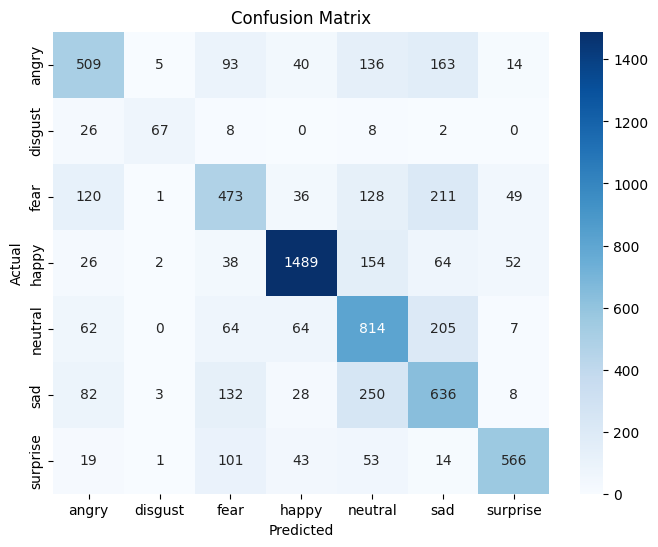

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load the best model
BEST_MODEL = "/kaggle/working/best.pth"
test_model = OurModel(7).to(device)
state_dict = torch.load(BEST_MODEL, map_location=torch.device('cpu'))
test_model.load_state_dict(state_dict["model_state_dict"])

acc, f1, cm = test(test_model, test_loader, device)

print(f"Accuracy: {acc:.4f}")
print(f"Test F1 Score: {f1:.4f}")

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise'], 
            yticklabels=['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()